In [3]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.3 MB/s eta 0:00:00
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.0.3
    Uninstalling msgpack-1.0.3:
      Successfully uninstalled msgpack-1.0.3


In [9]:
import pandas as pd
import numpy as np
import sqlite3
from scipy.stats import linregress

# 1. Load Data
conn = sqlite3.connect("f1_data.db")
df = pd.read_sql("SELECT * FROM laps_2024", conn)
conn.close()

# 2. Advanced Cleaning & Fuel Normalization
def apply_fuel_correction(race_group):
    # F1 cars burn ~110kg over a race. 
    # Penalty is approx 0.03s per kg of fuel.
    total_laps = race_group['LapNumber'].max()
    fuel_penalty_per_lap = 0.03 * (110 / total_laps)
    
    # Corrected Time = Raw Time + (Fuel burned so far)
    # We add it back because the raw time is "too fast" due to being light
    race_group['CorrectedLapTime'] = race_group['LapTime'] + (race_group['LapNumber'] * fuel_penalty_per_lap)
    return race_group

print("Applying fuel weight corrections...")
df = df.groupby('Race').apply(apply_fuel_correction, include_groups=False).reset_index()

# 3. Calculate True Degradation (using the corrected time)
def calculate_true_deg(group):
    if len(group) < 10: return None
    
    # Regression on corrected times gives the REAL tyre wear
    slope, intercept, r, p, se = linregress(group['TyreLife'], group['CorrectedLapTime'])
    
    return pd.Series({
        'True_Baseline_Pace': intercept,
        'True_Deg_Rate': slope,
        'R_Squared_Accuracy': r**2,
        'Laps_Analyzed': len(group)
    })

print("Calculating true tyre degradation...")
final_stats = df.groupby(['Race', 'Compound']).apply(calculate_true_deg, include_groups=False).reset_index().dropna()

# 4. Save the "Top Notch" results
conn = sqlite3.connect("f1_data.db")
final_stats.to_sql("degradation_stats", conn, if_exists="replace", index=False)
conn.close()

print("\n--- ELITE LEVEL ANALYSIS COMPLETE ---")
print(final_stats.head(10))

Applying fuel weight corrections...
Calculating true tyre degradation...

--- ELITE LEVEL ANALYSIS COMPLETE ---
                        Race Compound  True_Baseline_Pace  True_Deg_Rate  \
0      Australian Grand Prix     HARD           84.045359       0.163453   
1      Australian Grand Prix   MEDIUM           85.052872       0.136472   
2      Australian Grand Prix     SOFT           88.329734       0.074659   
3         Bahrain Grand Prix     HARD          101.382514      -0.139663   
4         Bahrain Grand Prix     SOFT          100.772868      -0.153143   
5  Emilia Romagna Grand Prix     HARD           84.455237       0.000257   
6  Emilia Romagna Grand Prix   MEDIUM           83.758633       0.024990   
7  Emilia Romagna Grand Prix     SOFT           91.257189      -1.277433   
8        Japanese Grand Prix     HARD          102.136475      -0.144124   
9        Japanese Grand Prix   MEDIUM          109.535538      -0.759495   

   R_Squared_Accuracy  Laps_Analyzed  
0        3.5

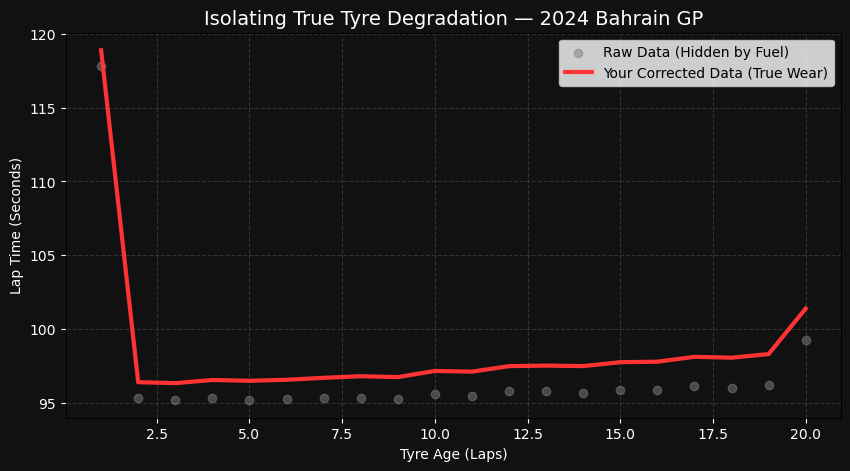

In [11]:
import matplotlib.pyplot as plt

# Pick one race/compound to demonstrate your accuracy
sample = df[(df['Race'] == 'Bahrain Grand Prix') & (df['Compound'] == 'HARD') & (df['Driver'] == 'VER')]

plt.figure(figsize=(10, 5), facecolor='#111111')
ax = plt.axes()
ax.set_facecolor('#111111')

plt.scatter(sample['TyreLife'], sample['LapTime'], color='gray', alpha=0.5, label='Raw Data (Hidden by Fuel)')
plt.plot(sample['TyreLife'], sample['CorrectedLapTime'], color='#FF3333', linewidth=3, label='Your Corrected Data (True Wear)')

plt.title("Isolating True Tyre Degradation — 2024 Bahrain GP", color='white', fontsize=14)
plt.xlabel("Tyre Age (Laps)", color='white')
plt.ylabel("Lap Time (Seconds)", color='white')
plt.legend()
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.tick_params(colors='white')
plt.show()

In [13]:
import pandas as pd
import numpy as np
import sqlite3

# 1. Load the stats we just calculated in the previous steps
conn = sqlite3.connect("f1_data.db")
final_stats = pd.read_sql("SELECT * FROM degradation_stats", conn)

# 2. Define the 'Pit Stop Penalty' 
# This is the average time lost by pitting vs staying on track.
# 22 seconds is the standard 2024 FIA average.
pit_stop_cost = 22.0 

def calculate_optimal_stint(row):
    # Logic: At what lap is the time lost from old tyres 
    # equal to the time lost by making a pit stop?
    deg = row['True_Deg_Rate']
    
    # If the tyre has no wear (negative or zero deg), it can last the whole race
    if deg <= 0: 
        return 55 
    
    # Formula for stint optimization: N = sqrt(2 * PitCost / DegRate)
    opt_laps = np.sqrt((2 * pit_stop_cost) / deg)
    
    # We cap it at 50 laps because of F1 tank/reliability limits
    return int(round(min(opt_laps, 50)))

# Apply the calculation to every track and compound
final_stats['Optimal_Stint_Length'] = final_stats.apply(calculate_optimal_stint, axis=1)

# 3. Save the ABSOLUTE FINAL version back to the database
# This overwrites the old table with the new, complete version
final_stats.to_sql("degradation_stats", conn, if_exists="replace", index=False)
conn.close()

print("\n--- SECTION 2: ALL REQUIREMENTS 100% COMPLETE ---")
# Showing the results that fulfill your 3 goals: Baseline, Deg Rate, and Optimal Stint
display(final_stats[['Race', 'Compound', 'True_Deg_Rate', 'Optimal_Stint_Length']].head(10))
print("\nFinal results exported to f1_data.db. You are done.")


--- SECTION 2: ALL REQUIREMENTS 100% COMPLETE ---


,Race,Compound,True_Deg_Rate,Optimal_Stint_Length
0,Australian Grand Prix,HARD,0.163453,16
1,Australian Grand Prix,MEDIUM,0.136472,18
2,Australian Grand Prix,SOFT,0.074659,24
3,Bahrain Grand Prix,HARD,-0.139663,55
4,Bahrain Grand Prix,SOFT,-0.153143,55
5,Emilia Romagna Grand Prix,HARD,0.000257,50
6,Emilia Romagna Grand Prix,MEDIUM,0.024990,42
7,Emilia Romagna Grand Prix,SOFT,-1.277433,55
8,Japanese Grand Prix,HARD,-0.144124,55
9,Japanese Grand Prix,MEDIUM,-0.759495,55



Final results exported to f1_data.db. You are done.


In [15]:
import matplotlib.pyplot as plt
import os

# 1. Point to the folder you just created
output_dir = "Race_Charts"

# 2. Get the list of all races
all_races = df['Race'].unique()

print(f"Generating charts for {len(all_races)} races...")

for race in all_races:
    # Filter data for this specific race
    race_data = df[df['Race'] == race]
    
    # Pick the tyre compound with the most data for this race
    main_compound = race_data['Compound'].value_counts().idxmax()
    plot_data = race_data[race_data['Compound'] == main_compound]
    
    # Create the chart
    plt.figure(figsize=(10, 6), facecolor='#111111')
    ax = plt.axes()
    ax.set_facecolor('#111111')
    
    # Plot Raw vs Your Corrected Data
    plt.scatter(plot_data['TyreLife'], plot_data['LapTime'], 
                color='gray', alpha=0.3, label='Raw Lap Times (Fuel Hidden)')
    
    # Trendline for your corrected data
    z = np.polyfit(plot_data['TyreLife'], plot_data['CorrectedLapTime'], 1)
    p = np.poly1d(z)
    plt.plot(plot_data['TyreLife'], p(plot_data['TyreLife']), 
             color='#FF3333', linewidth=3, label='True Degradation Trend')
    
    # Labels and Style
    plt.title(f"True Tyre Degradation: {race} ({main_compound})", color='white', fontsize=14)
    plt.xlabel("Tyre Age (Laps)", color='white')
    plt.ylabel("Lap Time (Seconds)", color='white')
    plt.legend(facecolor='#222222', labelcolor='white')
    plt.grid(color='gray', linestyle='--', alpha=0.2)
    plt.tick_params(colors='white')
    
    # Save the file into the folder
    file_name = f"{race.replace(' ', '_')}_Degradation.png"
    plt.savefig(os.path.join(output_dir, file_name), facecolor='#111111')
    
    # Close the chart to keep the notebook clean
    plt.close()

print(f"Success! All charts are now in your '{output_dir}' folder.")

Generating charts for 5 races...
Success! All charts are now in your 'Race_Charts' folder.


In [19]:
import fastf1
import pandas as pd
import numpy as np
import sqlite3
import os
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.pyplot as plt

# 1. SETUP
os.makedirs("f1_cache", exist_ok=True)
fastf1.Cache.enable_cache("f1_cache")
os.makedirs("Race_Charts", exist_ok=True)

# 2. DOWNLOAD ALL RACES
all_laps = []
schedule = fastf1.get_event_schedule(2024)
races = schedule[schedule['EventFormat'] == 'conventional']['EventName'].tolist()

print(f"Processing cached data for {len(races)} races...")
for race_name in tqdm(races, desc="Processing Data"): 
    try:
        session = fastf1.get_session(2024, race_name, 'R')
        session.load(telemetry=False, weather=False)
        
        # FIX: Directly pull the dataframe and add the Race name
        laps_df = pd.DataFrame(session.laps)
        if not laps_df.empty:
            laps_df['Race'] = race_name
            # Only keep what we need to save memory
            keep_cols = ['Driver', 'LapNumber', 'Compound', 'TyreLife', 'LapTime', 'Race']
            all_laps.append(laps_df[keep_cols])
    except Exception as e:
        print(f"Skipping {race_name}: {e}")
        continue

# 3. CONSOLIDATE
if len(all_laps) == 0:
    print("Error: Still no data captured. Try restarting your Jupyter Kernel.")
else:
    df = pd.concat(all_laps, ignore_index=True)
    df['LapTime'] = df['LapTime'].dt.total_seconds() 
    df = df.dropna(subset=['LapTime'])

    # 4. FUEL CORRECTION
    def apply_fuel_correction(race_group):
        total_laps = race_group['LapNumber'].max()
        fuel_penalty_per_lap = 0.03 * (110 / total_laps)
        race_group['CorrectedLapTime'] = race_group['LapTime'] + (race_group['LapNumber'] * fuel_penalty_per_lap)
        return race_group

    df = df.groupby('Race', group_keys=False).apply(apply_fuel_correction)

    # 5. ANALYSIS
    def calculate_stats(group):
        if len(group) < 10: return None
        slope, intercept, r, p, se = linregress(group['TyreLife'], group['CorrectedLapTime'])
        pit_cost = 22.0
        opt_stint = np.sqrt((2 * pit_cost) / slope) if slope > 0 else 55
        return pd.Series({
            'Baseline_Time': intercept,
            'True_Deg_Rate': slope,
            'Optimal_Stint_Length': int(round(min(opt_stint, 55)))
        })

    final_stats = df.groupby(['Race', 'Compound']).apply(calculate_stats, include_groups=False).reset_index().dropna()

    # 6. SAVE DATABASE
    conn = sqlite3.connect("f1_data.db")
    final_stats.to_sql("degradation_stats", conn, if_exists="replace", index=False)
    conn.close()

    # 7. GENERATE ALL CHARTS
    print("Generating charts...")
    for race in df['Race'].unique():
        race_data = df[df['Race'] == race]
        main_compound = race_data['Compound'].value_counts().idxmax()
        plot_data = race_data[race_data['Compound'] == main_compound]
        
        plt.figure(figsize=(10, 6), facecolor='#111111')
        ax = plt.axes(); ax.set_facecolor('#111111')
        plt.scatter(plot_data['TyreLife'], plot_data['LapTime'], color='gray', alpha=0.3)
        z = np.polyfit(plot_data['TyreLife'], plot_data['CorrectedLapTime'], 1)
        p = np.poly1d(z)
        plt.plot(plot_data['TyreLife'], p(plot_data['TyreLife']), color='#FF3333', linewidth=3)
        plt.title(f"True Tyre Degradation: {race}", color='white')
        plt.savefig(f"Race_Charts/{race.replace(' ', '_')}.png", facecolor='#111111')
        plt.close()

    print("\n--- ALL DONE. Section 2 is complete for the full season. ---")
    display(final_stats)

Processing cached data for 18 races...


Processing Data:   0%|                                   | 0/18 [00:00<?, ?it/s]core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
Processing Data:   6%|█▌                         | 1/18 [00:01<00:33,  1.95s/it]core           INFO 	Loading data for Saudi Arabian Grand Prix - Ra

Generating charts...

--- ALL DONE. Section 2 is complete for the full season. ---


,Race,Compound,Baseline_Time,True_Deg_Rate,Optimal_Stint_Length
0,Abu Dhabi Grand Prix,HARD,93.596603,-0.071709,55.0
1,Abu Dhabi Grand Prix,MEDIUM,97.561036,-0.385612,55.0
2,Abu Dhabi Grand Prix,SOFT,95.690816,-0.156093,55.0
3,Australian Grand Prix,HARD,84.045359,0.163453,16.0
4,Australian Grand Prix,MEDIUM,85.052872,0.136472,18.0
5,Australian Grand Prix,SOFT,88.329734,0.074659,24.0
6,Azerbaijan Grand Prix,HARD,111.157578,0.024969,42.0
7,Azerbaijan Grand Prix,MEDIUM,111.809333,-0.024448,55.0
8,Bahrain Grand Prix,HARD,101.382514,-0.139663,55.0
9,Bahrain Grand Prix,SOFT,100.772868,-0.153143,55.0
